<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/cosmology_expansion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Expansion of the Universe**

from book [Introduction to Astronomy and Astrophysics](https://www.physik.uni-hamburg.de/en/hs/group---schmidt/teaching.html#v-33029000)

In [ ]:
!git clone https://github.com/deltorobarba/astrophysics.git
%cd astrophysics
import numkit

In [4]:
import numpy as np
import astropy.units as unit
from numkit import rk4_step

In [5]:
# Hubble constant with astropy units
H0 = 67.7*unit.km/unit.s/unit.Mpc
print("H0 = {:.2e}".format(H0.to(1/unit.Gyr)))

# dictionary of cosmological models
cosmology = {
    'standard' : (0.309, 1e-5, 0.691),
    'matter sub'   : (0.309, 1e-5, 0),
    'matter crit'  : (1, 0, 0),
    'matter super' : (2, 0, 0),
}

H0 = 6.92e-02 1 / Gyr


Friedmann equation

In [6]:
def dota(t, a, OmegaM, OmegaR, OmegaL, H0):
    Omega0 = OmegaM + OmegaR + OmegaL
    return H0 * (OmegaM/a + OmegaR/a**2 + OmegaL*a**2 + 1 - Omega0)**(1/2)

Test of numerical time step

In [7]:
# numerical values for time in Gyr
H0_num = H0.to(1/unit.Gyr).value
t_H = 1/H0_num

t_max = 0.1*t_H
n = 10

while n <= 1000:
    t, a = 0, 0.01 # initial values
    dt = t_max/n   # time step

    # numerical integration from 0 to t_max
    for i in range(n):
        a = rk4_step(dota, t, a, dt, *cosmology['standard'], H0_num)
        t += dt

    print("{:4d} {:.8e}".format(n,a))
    n *= 2

  10 1.93079317e-01
  20 1.92796594e-01
  40 1.92753019e-01
  80 1.92748144e-01
 160 1.92747742e-01
 320 1.92747714e-01
 640 1.92747713e-01


**Integration of Friedmann equation**

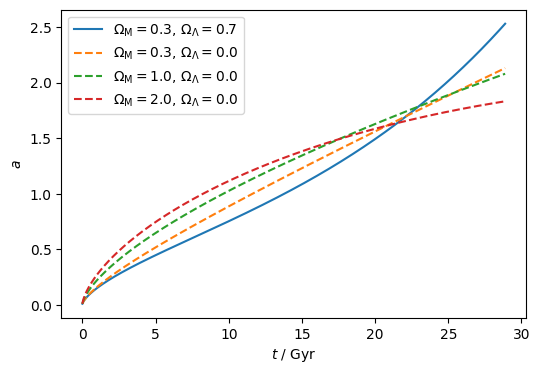

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(6, 4), dpi=100)

n = 1000
dt = 2*t_H/n
t = np.linspace(0, 2*t_H, n+1)

for model in cosmology:
    a = np.zeros(n+1)
    a[0] = 1e-2

    # numerical integration of the model
    for i in range(n):
        a[i+1] = rk4_step(dota, t[i], a[i], dt, *cosmology[model], H0_num)

    # plot the scale factor as function of time
    label = "$\Omega_{\mathrm{M}}=$"
    label += "{:.1f}, $\Omega_\Lambda=${:.1f}".\
        format(cosmology[model][0],cosmology[model][2])
    if model == "standard":
        plt.plot(t, a, label=label)
    else:
        plt.plot(t, a, ls='dashed', label=label)

plt.xlabel("$t$ / Gyr")
plt.ylabel("$a$")
plt.legend()
plt.savefig("scale_fct_evol.pdf")

**Standard cosmology: transition time**

In [9]:
n = int(t_H/dt)
a = np.zeros(n+1)
a[0] = 1e-2

for i in range(n):
    a[i+1] = rk4_step(dota, i*dt, a[i], dt, *cosmology['standard'], H0_num)

# compute second derivative of scale factor
# and terminate if sign reverses
i = 0
ddota = -1 # arbitrary start value
while ddota < 0 and i < n:
    i += 1
    # second-order centered differences
    ddota = (a[i+1] - 2*a[i] + a[i-1])/dt**2

if ddota >= 0:
    print("Transition time = {:.2f} Gyr".format(i*dt))
else:
    print("Transition time not reached")

Transition time = 7.63 Gyr
